In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)
X = X.ravel() 
y = y.ravel()

In [3]:
b = -520
m = 600
lr = 0.001
epochs = 30

all_b, all_m, all_cost = [], [], []

In [4]:
for i in range(epochs):
    # Calculate error for all 100 points at once
    error = y - (m * X) - b
    
    # Calculate slopes and total cost
    slope_b = -2 * np.sum(error)
    slope_m = -2 * np.sum(error * X)
    cost = np.sum(error**2)
    
    # Update parameters
    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    
    # Store history for the animation
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

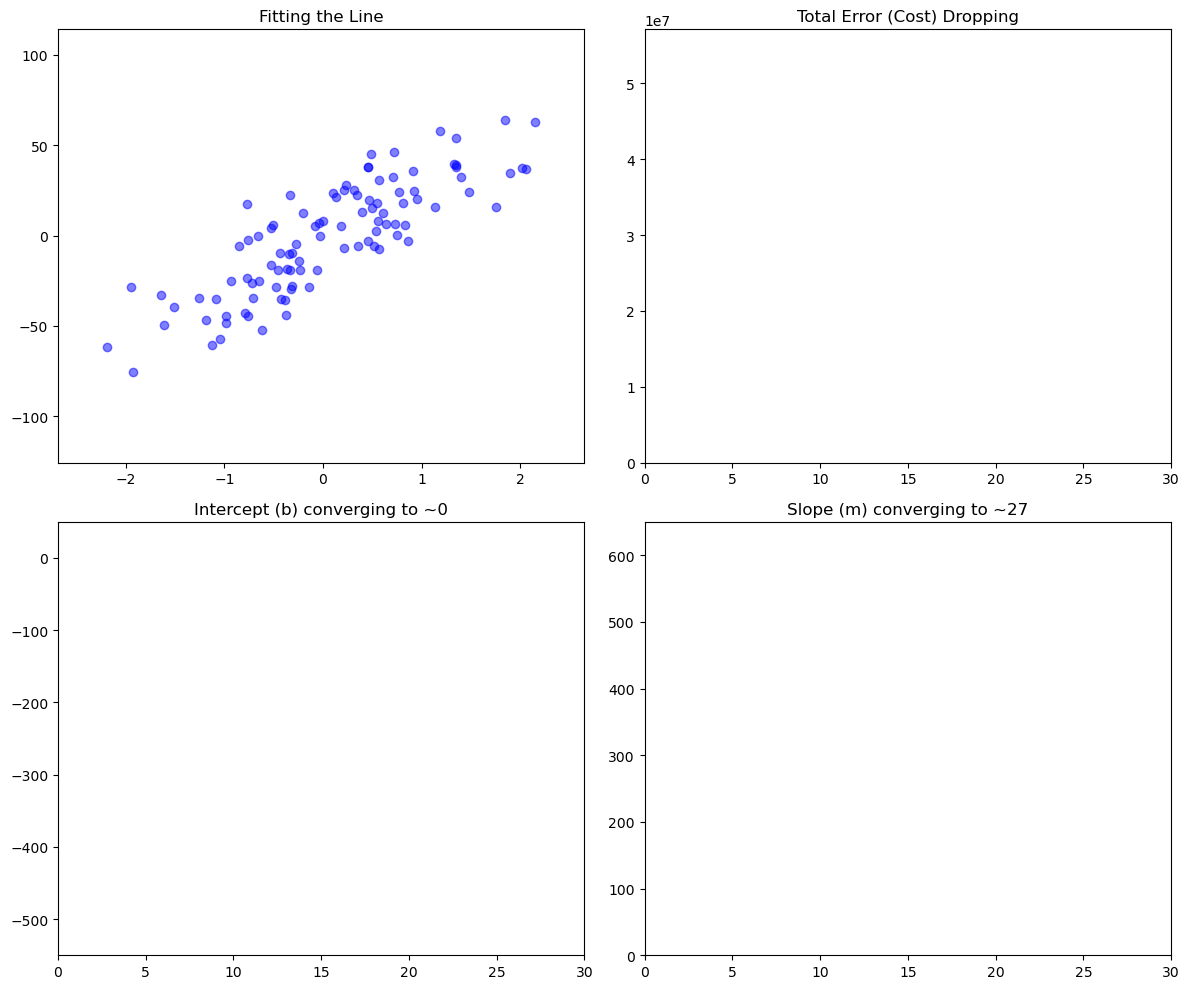

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
ax_line, ax_cost, ax_b, ax_m = axs.flatten()

# --- Top Left: The Moving Line ---
ax_line.scatter(X, y, color='blue', alpha=0.5)
line_fit, = ax_line.plot([], [], color='red', lw=2)
ax_line.set_title("Fitting the Line")
ax_line.set_xlim(X.min() - 0.5, X.max() + 0.5)
ax_line.set_ylim(y.min() - 50, y.max() + 50)

# --- Top Right: Cost vs Epochs ---
cost_line, = ax_cost.plot([], [], color='green', lw=2)
cost_dot, = ax_cost.plot([], [], 'ro')
ax_cost.set_title("Total Error (Cost) Dropping")
ax_cost.set_xlim(0, epochs)
ax_cost.set_ylim(0, max(all_cost) * 1.1)

# --- Bottom Left: Intercept (b) vs Epochs ---
b_line, = ax_b.plot([], [], color='purple', lw=2)
b_dot, = ax_b.plot([], [], 'ro')
ax_b.set_title("Intercept (b) converging to ~0")
ax_b.set_xlim(0, epochs)
ax_b.set_ylim(-550, 50)

# --- Bottom Right: Slope (m) vs Epochs ---
m_line, = ax_m.plot([], [], color='orange', lw=2)
m_dot, = ax_m.plot([], [], 'ro')
ax_m.set_title("Slope (m) converging to ~27")
ax_m.set_xlim(0, epochs)
ax_m.set_ylim(0, 650)

plt.tight_layout()

In [6]:
def animate(i):
    # Update Line
    line_fit.set_data(X, all_m[i] * X + all_b[i])
    
    # Update Cost (draws line up to current epoch, places dot at tip)
    cost_line.set_data(range(i+1), all_cost[:i+1])
    cost_dot.set_data([i], [all_cost[i]])
    
    # Update b
    b_line.set_data(range(i+1), all_b[:i+1])
    b_dot.set_data([i], [all_b[i]])
    
    # Update m
    m_line.set_data(range(i+1), all_m[:i+1])
    m_dot.set_data([i], [all_m[i]])
    
    # Update Master Title
    fig.suptitle(f"Epoch: {i+1}/{epochs} | m: {all_m[i]:.1f} | b: {all_b[i]:.1f} | Cost: {all_cost[i]:.0f}", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    return line_fit, cost_line, cost_dot, b_line, b_dot, m_line, m_dot

In [7]:
print("Rendering full dashboard animation...")
anim = FuncAnimation(fig, animate, frames=epochs, interval=200, blit=False)
anim.save("full_gradient_descent_dashboard.gif", writer=PillowWriter(fps=5))
print("Done! Saved as full_gradient_descent_dashboard.gif")

Rendering full dashboard animation...
Done! Saved as full_gradient_descent_dashboard.gif
